In [1]:
'''
Here we compared the facultative sex under diploid and the previous results under 45-ploid.

We simulated facultative sex with mitosis, also with a sexual frequency of every 100 generations, and compared the new results 
with our previous findings on facultative sex with amitosis.

N = 2K and all mutations are deleterious.

'''

'\nHere we compared the facultative sex under diploid and the previous results under 45-ploid.\n\nWe simulated facultative sex with mitosis, also with a sexual frequency of every 100 generations, and compared the new results \nwith our previous findings on facultative sex with amitosis.\n\nN = 2K and all mutations are deleterious.\n\n'

In [2]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_mean = []
    total_soma_mu_std = []

    total_germ_mu_mean = []
    total_germ_mu_std = []
    
    total_soma_genomic_mu_mean = []
    total_soma_genomic_mu_std = []    
    
    total_germ_genomic_mu_mean = []
    total_germ_genomic_mu_std = []  
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_mean = []
        soma_mu_std = []
        
        germ_mu_mean = []
        germ_mu_std = []        
        
        soma_genomic_mu_mean = []
        soma_genomic_mu_std = []
        
        germ_genomic_mu_mean = []
        germ_genomic_mu_std = []   
        
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_mean.extend(list(pd.Series(f.SomaMu_Mean,dtype=float)))
        soma_mu_std.extend(list(pd.Series(f.SomaMu_Std,dtype=float)))
        
        germ_mu_mean.extend(list(pd.Series(f.GermMu_Mean,dtype=float)))
        germ_mu_std.extend(list(pd.Series(f.GermMu_Std,dtype=float)))   
        
        soma_genomic_mu_mean.extend(list(pd.Series(f.SomaGenomicMu_Mean,dtype=float)))
        soma_genomic_mu_std.extend(list(pd.Series(f.SomaGenomicMu_Std,dtype=float)))
        
        germ_genomic_mu_mean.extend(list(pd.Series(f.GermGenomicMu_Mean,dtype=float)))
        germ_genomic_mu_std.extend(list(pd.Series(f.GermGenomicMu_Std,dtype=float)))        
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_mean.append(soma_mu_mean)
        total_soma_mu_std.append(soma_mu_std)  
        
        total_germ_mu_mean.append(germ_mu_mean)
        total_germ_mu_std.append(germ_mu_std)    

        
        total_soma_genomic_mu_mean.append(soma_genomic_mu_mean)
        total_soma_genomic_mu_std.append(soma_genomic_mu_std)  
        
        total_germ_genomic_mu_mean.append(germ_genomic_mu_mean)
        total_germ_genomic_mu_std.append(germ_genomic_mu_std) 
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_mean, total_soma_mu_std, \
total_germ_mu_mean, total_germ_mu_std, total_soma_genomic_mu_mean, total_soma_genomic_mu_std, \
total_germ_genomic_mu_mean, total_germ_genomic_mu_std

## N = 2K_RME100 with amitosis_P = 2

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\3. Eff = 0.9_Low Mu = 0.002 and Up Mu = 0.01_Diploid\1. Dele\N2K")

In [5]:
og_fit_file = ['Fit_RME100_P2_N2K_Dele_SameIntMuPerLocus_MuEvo_191115.csv']

og = get_data1(og_fit_file)

og_fit_mean =og[0]
og_fit_std = og[1]

og_sm_mu_mean = og[2]
og_sm_mu_std = og[3]

og_gm_mu_mean = og[4]
og_gm_mu_std = og[5]

og_sm_genomic_mu_mean = og[6]
og_sm_genomic_mu_std = og[7]

og_gm_genomic_mu_mean = og[8]
og_gm_genomic_mu_std = og[9]

In [17]:
print 'P2 FS Fit', og_fit_mean[0][-1], og_fit_mean[0][-1]-1.98*og_fit_std[0][-1]/10, og_fit_mean[0][-1]+1.98*og_fit_std[0][-1]/10

P2 FS Fit 0.990619389018 0.988374140187 0.992864637848


In [21]:
print 'P2 FS MAC Mu', og_sm_mu_mean[0][-1]/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100)

P2 FS MAC Mu 0.246351375256 0.181527148478 0.311175602035


In [22]:
print 'P2 FS MIC Mu', og_gm_mu_mean[0][-1]/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100)

P2 FS MIC Mu 0.244492963925 0.179665697838 0.309320230013


## N = 2K_RME100 with Amitosis_P = 45

In [23]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2. Eff = 0.9_Lower Mu = 0.002 and Upper Mu = 0.01\1. Dele Only\N2K")

In [24]:
rv_fit_file = ['Fit_RME100_N2K_DeleOnly_UP01LW002_MuEvo_190910R2.csv']

rv = get_data1(rv_fit_file)

rv_fit_mean =rv[0]
rv_fit_std = rv[1]

rv_sm_mu_mean = rv[2]
rv_sm_mu_std = rv[3]

rv_gm_mu_mean = rv[4]
rv_gm_mu_std = rv[5]

rv_sm_genomic_mu_mean = rv[6]
rv_sm_genomic_mu_std = rv[7]

rv_gm_genomic_mu_mean = rv[8]
rv_gm_genomic_mu_std = rv[9]

In [25]:
print 'P45 FS', rv_fit_mean[0][-1], rv_fit_mean[0][-1]-1.98*rv_fit_std[0][-1]/10, rv_fit_mean[0][-1]+1.98*rv_fit_std[0][-1]/10

P45 FS 0.996028681249 0.994984278735 0.997073083764


In [29]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

In [30]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [31]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


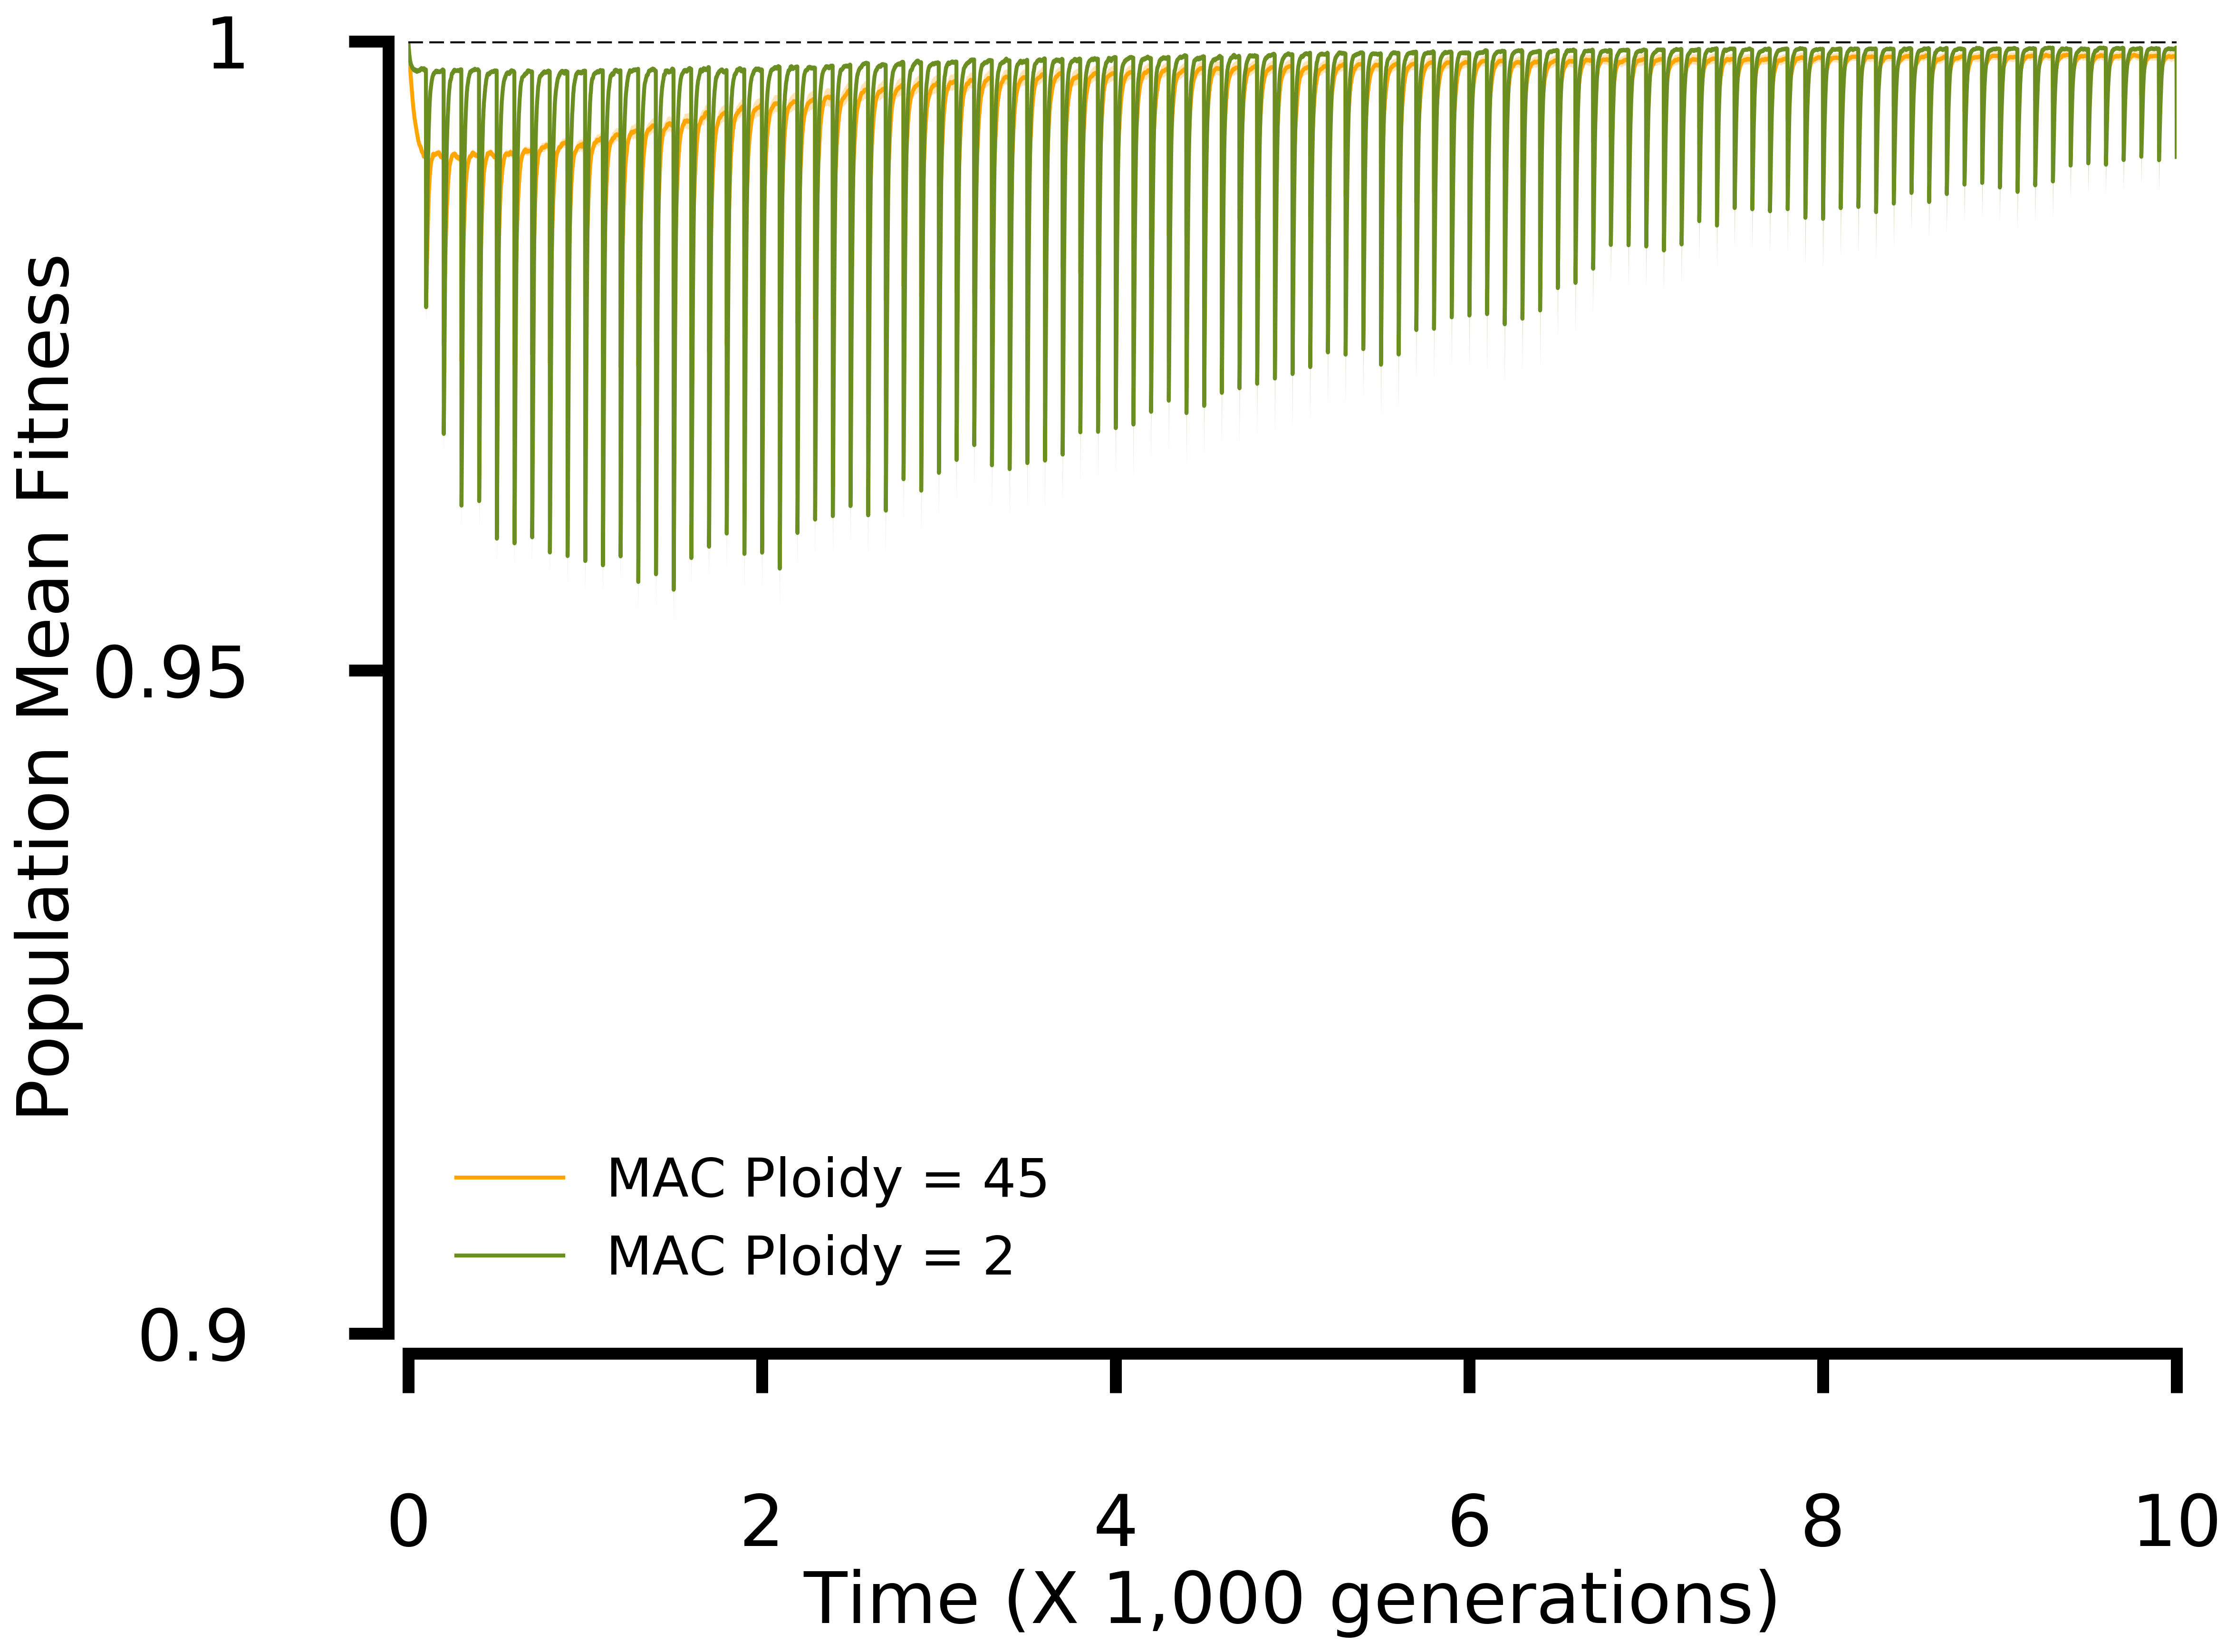

In [33]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10*1000)

t = generation_list

a1 = og_fit_mean[0]
error_a1 = list(1.98* np.array(og_fit_std[0])/((100)**0.5))


a3 = rv_fit_mean[0]
error_a3 = list(1.98* np.array(rv_fit_std[0])/((100)**0.5))



# ax.set_title('Fit_Dele_Evo of Mu_Same Initial Mu Per Locus_FS with Amito_N = 2K', fontsize =26)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =36)
ax.set_ylabel('Population Mean Fitness', fontsize =36)


# ax.semilogy(t, a, )

ax.set_yscale('log')

ax.plot(t,a3,'orange', label = 'MAC Ploidy = 45',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='orange')



ax.plot(t,a1,'olivedrab', label = 'MAC Ploidy = 2',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='olivedrab')



plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# plt.legend(loc='lower left', frameon=False, prop={'size':27})
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')

plt.legend(loc='lower left', frameon=False, prop={'size':27})

ax.set_ylim(0.9,1)

ax.set_yticks([0.9, 0.95, 1]) # choose which x locations to have ticks
ax.set_yticklabels([ 0.9, 0.95, 1]) # set the labels to display at those ticks



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

In [34]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

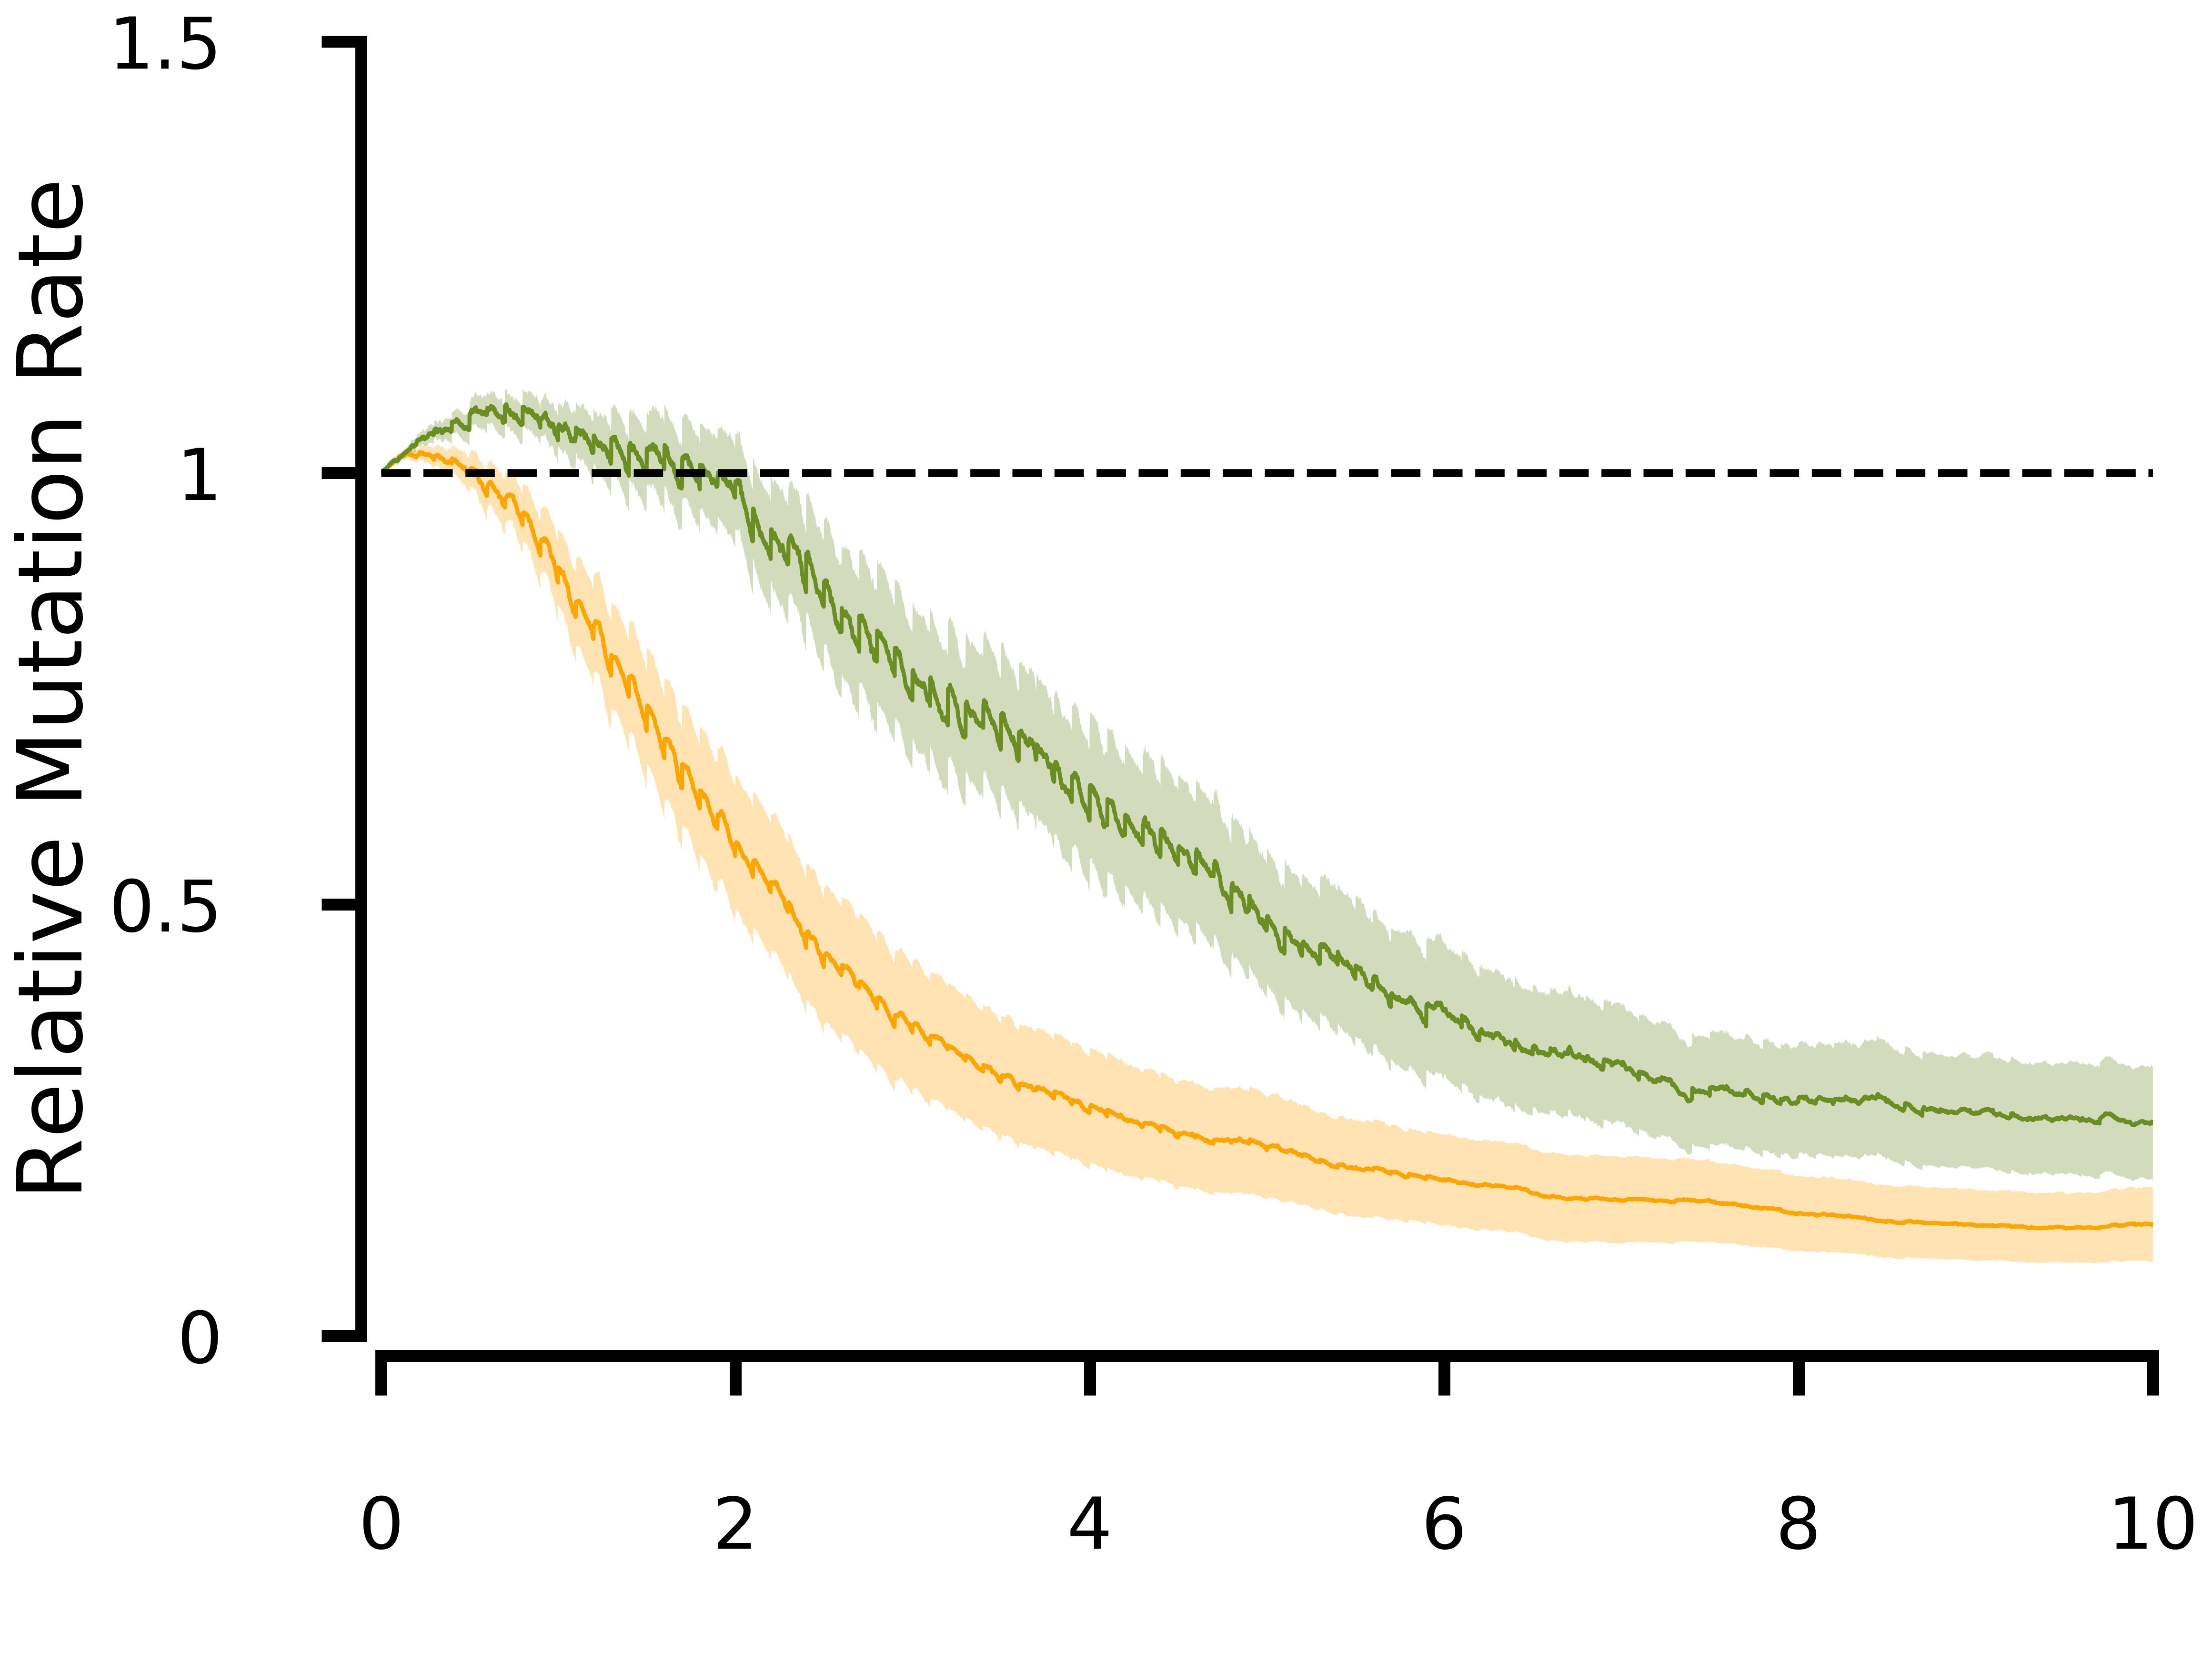

In [29]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10*1000)
ax.set_ylim(0,1.5)

t = generation_list

a1 = np.array(og_sm_mu_mean[0])/(0.1/(45*100))
error_a1 = 1.98* np.array(og_sm_mu_std[0])/((100)**0.5)/(0.1/(45*100))


a3 = np.array(rv_sm_mu_mean[0])/(0.1/(45*100))
error_a3 = 1.98* np.array(rv_sm_mu_std[0])/((100)**0.5)/(0.1/(45*100))



ax.set_xlabel('Time (X 1,000 generations)', fontsize =45, color = 'white')
ax.set_ylabel('Relative Mutation Rate', fontsize =45)



ax.plot(t,a3,'orange', label = 'MAC Ploidy = 45',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='orange')


ax.plot(t,a1,'olivedrab', label = 'MAC Ploidy = 2',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='olivedrab')



plt.axhline(y= 0.1/(45*100)/(0.1/(45*100)), linewidth=4.0, color ='k',ls ='dashed')

ax.set_yticks([0,0.5, 1, 1.5]) # choose which x locations to have ticks
ax.set_yticklabels([0, 0.5, 1, 1.5]) # set the labels to display at those ticks

ax.minorticks_off()


# plt.legend(loc='upper left', frameon=False, prop={'size':27})


# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

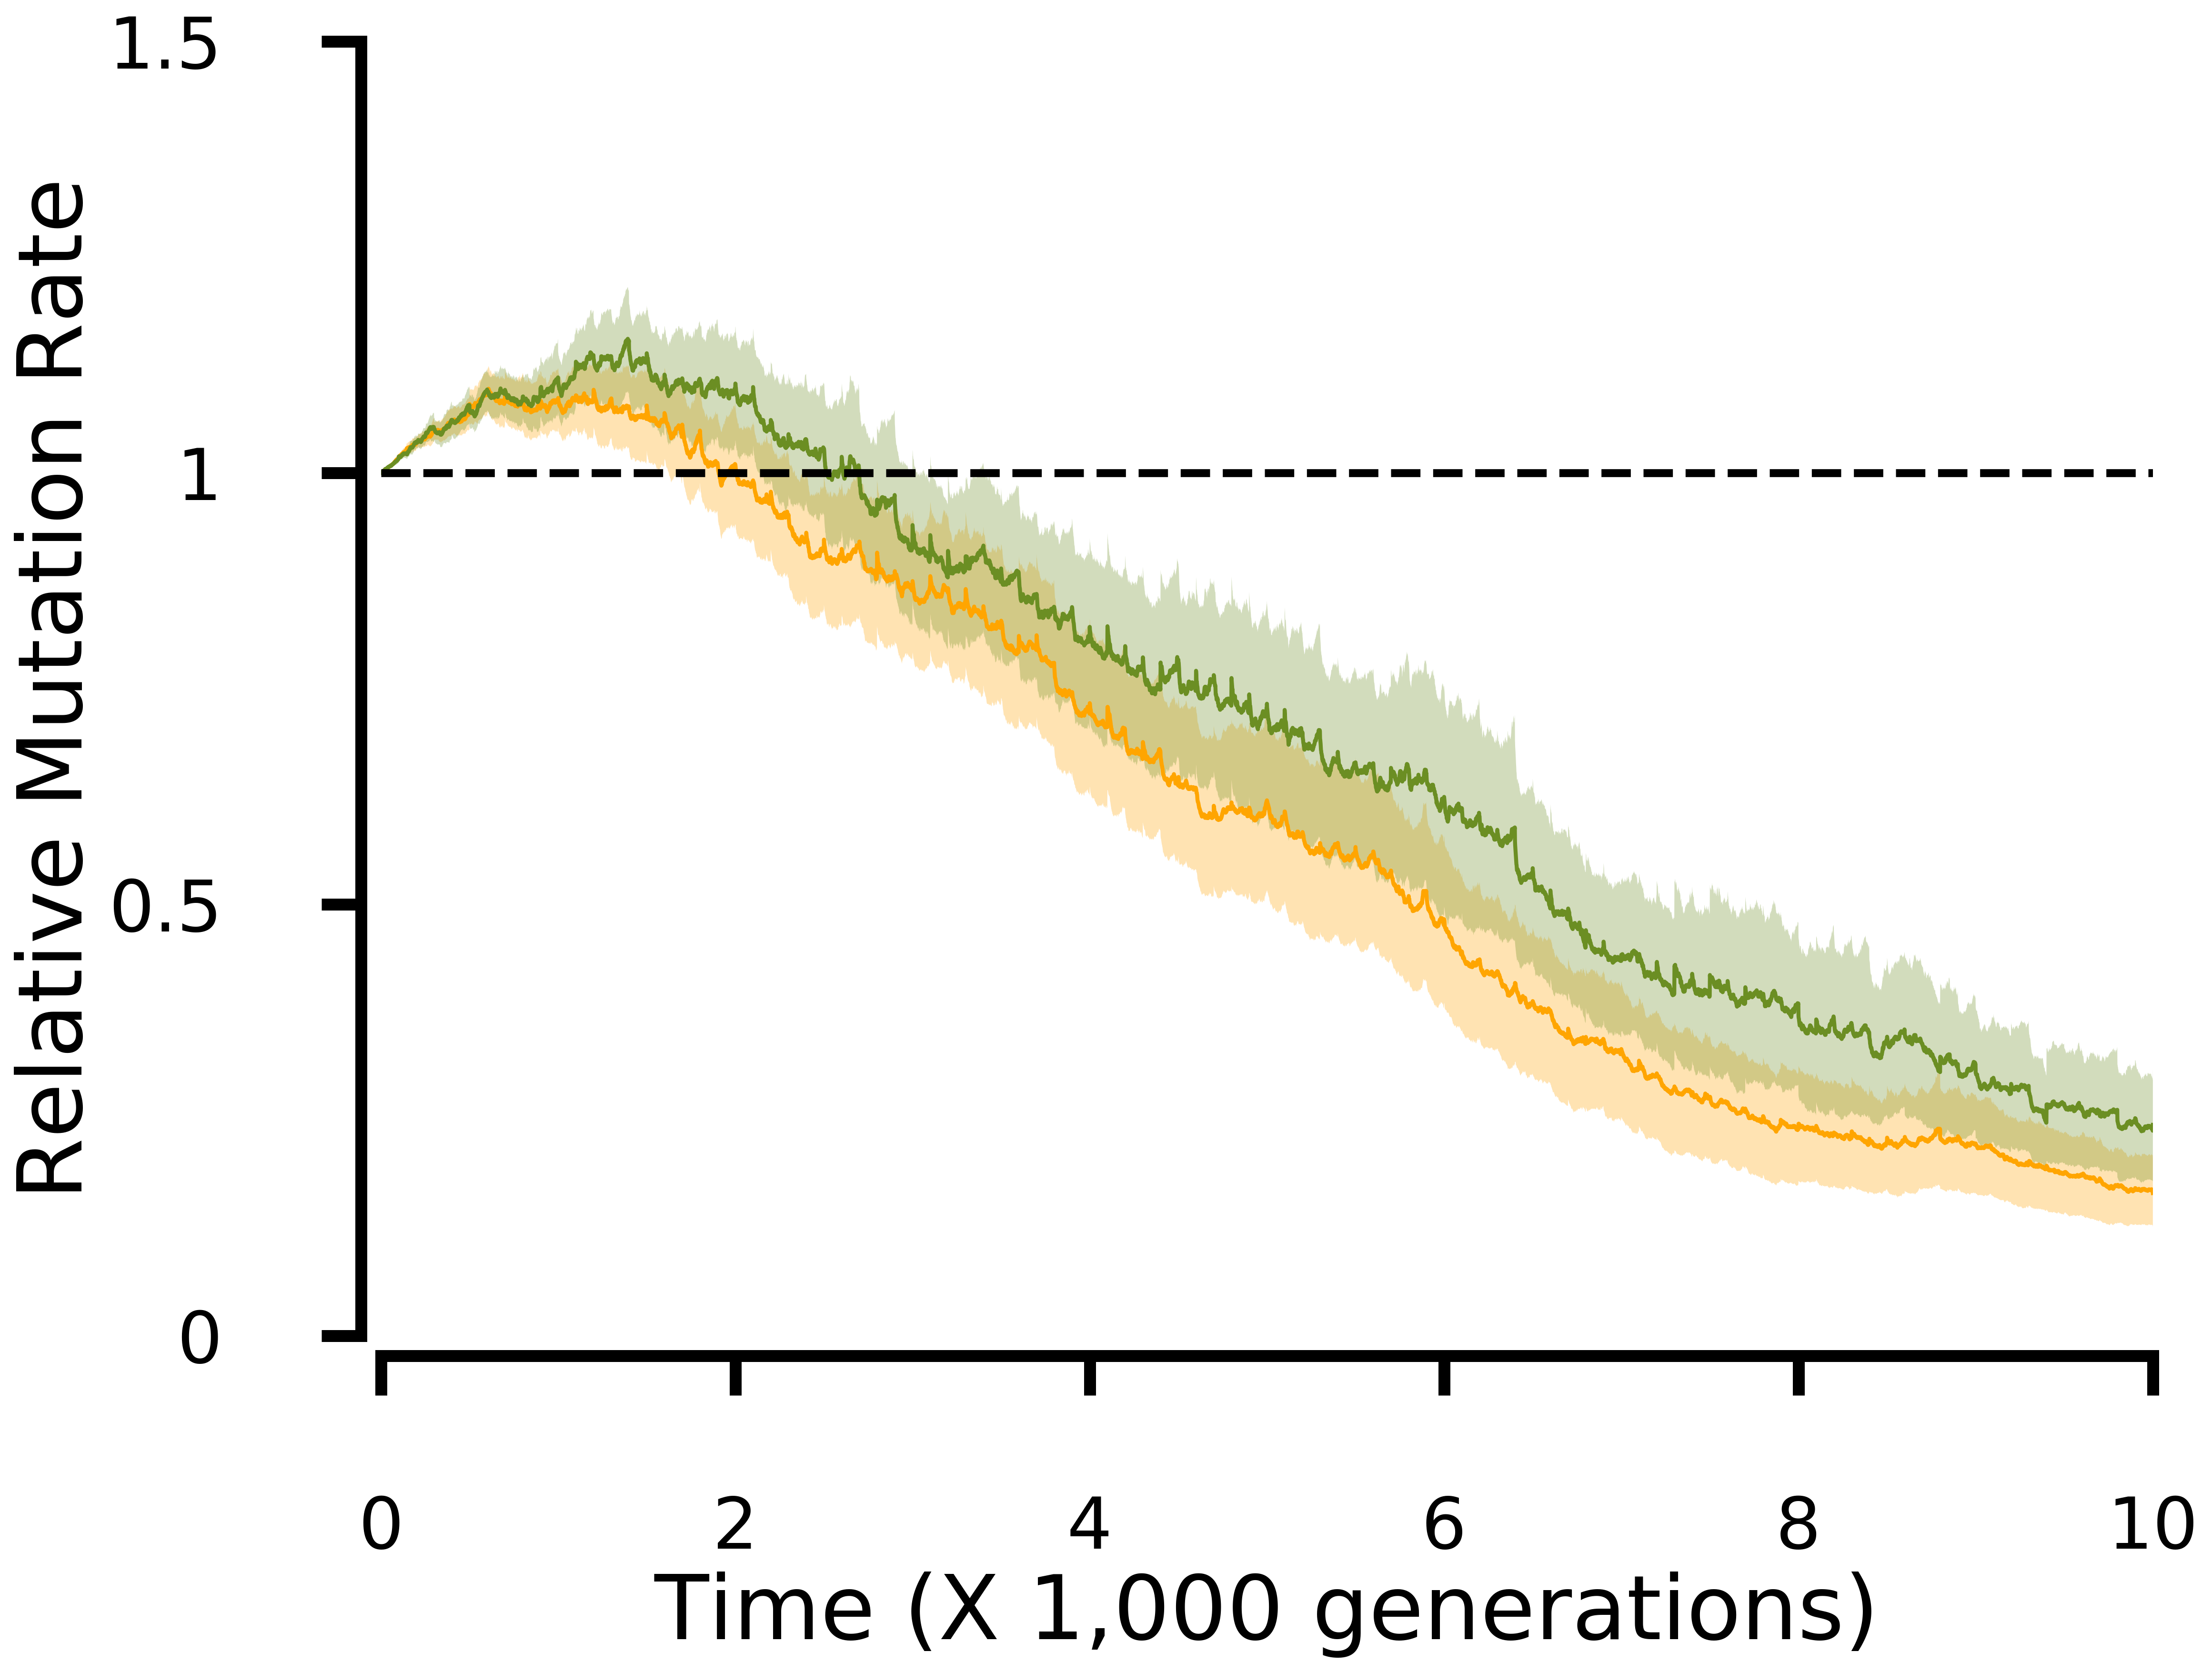

In [30]:
fig = plt.figure(figsize=(16, 12), dpi =300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,10*1000)
ax.set_ylim(0,1.5)

t = generation_list

a1 = np.array(og_gm_mu_mean[0])/(0.1/(45*100))
error_a1 = 1.98* np.array(og_gm_mu_std[0])/((100)**0.5)/(0.1/(45*100))


a3 = np.array(rv_gm_mu_mean[0])/(0.1/(45*100))
error_a3 = 1.98* np.array(rv_gm_mu_std[0])/((100)**0.5)/(0.1/(45*100))



ax.set_xlabel('Time (X 1,000 generations)', fontsize =45)
ax.set_ylabel('Relative Mutation Rate', fontsize =45)



ax.plot(t,a3,'orange', label = 'MAC Ploidy = 45',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='orange')


ax.plot(t,a1,'olivedrab', label = 'MAC Ploidy = 2',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='olivedrab')



plt.axhline(y= 0.1/(45*100)/(0.1/(45*100)), linewidth=4.0, color ='k',ls ='dashed')

ax.set_yticks([0,0.5, 1, 1.5]) # choose which x locations to have ticks
ax.set_yticklabels([0, 0.5, 1, 1.5]) # set the labels to display at those ticks

ax.minorticks_off()


# plt.legend(loc='upper left', frameon=False, prop={'size':27})


# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))